# **CÀI ĐẶT THƯ VIỆN**

In [1]:
!pip install yfinance pyswarms tensorflow scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import pyswarms as ps
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import yfinance as yf
from datetime import datetime
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
warnings.filterwarnings('ignore')

# **GET THE DATASET**

In [3]:
def lay_du_lieu_nang_cao(start_date="2010-01-01"):
    tickers = {
        'Gold': 'GC=F',
        'DXY': 'DX-Y.NYB',
        'Oil': 'CL=F',
        'S&P500': '^GSPC',
        'Bond_10Y': '^TNX'
    }
    all_data = yf.download(list(tickers.values()), start=start_date, auto_adjust=True)
    df = pd.DataFrame()
    df['Date'] = all_data.index
    df['Gold_Close'] = all_data['Close'][tickers['Gold']].values
    df['DXY'] = all_data['Close'][tickers['DXY']].values
    df['Oil'] = all_data['Close'][tickers['Oil']].values
    df['SP500'] = all_data['Close'][tickers['S&P500']].values
    df['Bond_Yield'] = all_data['Close'][tickers['Bond_10Y']].values
    df['Gold_Volume'] = all_data['Volume'][tickers['Gold']].values
    df = df.ffill().dropna()
    return df

In [4]:
df_benchmark = lay_du_lieu_nang_cao("2005-01-01")
df_benchmark

[*********************100%***********************]  5 of 5 completed


,Date,Gold_Close,DXY,Oil,SP500,Bond_Yield,Gold_Volume
0,2005-01-03,428.700012,81.300003,42.119999,1202.079956,4.220,4.0
1,2005-01-04,428.500000,82.570000,43.910000,1188.050049,4.283,108.0
2,2005-01-05,426.600006,82.540001,43.389999,1183.739990,4.277,2.0
3,2005-01-06,421.000000,83.150002,45.560001,1187.890015,4.272,1.0
4,2005-01-07,418.899994,83.610001,45.430000,1186.189941,4.285,1.0
...,...,...,...,...,...,...,...
5356,2026-04-06,4656.799805,99.980003,112.410004,6611.830078,4.335,148.0
5357,2026-04-07,4657.100098,99.639999,112.949997,6616.850098,4.343,327.0
5358,2026-04-08,4749.500000,99.129997,94.410004,6782.810059,4.291,405.0
5359,2026-04-09,4792.200195,98.820000,97.870003,6824.660156,4.293,1277.0


# Chuẩn bị dữ liệu & Hàm tạo dataset

In [5]:
def create_multivariate_dataset(data, look_back=60):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), :])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

In [7]:
df = df_benchmark.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

scaler_gold = MinMaxScaler(feature_range=(0, 1))
scaler_gold.fit(df[['Gold_Close']])

features_to_scale = df.drop(columns=['Date']).columns
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[features_to_scale])

num_features = scaled_data.shape[1]

In [8]:
# Xác định điểm chia train/test theo ngày
split_date = pd.to_datetime("2026-02-01")
# Tìm chỉ mục của ngày đầu tiên lớn hơn hoặc bằng split_date
split_index = df[df['Date'] >= split_date].index[0]
print(f"Dữ liệu sẽ được chia tại ngày {split_date.strftime('%Y-%m-%d')} (chỉ mục: {split_index}).")

Dữ liệu sẽ được chia tại ngày 2026-02-01 (chỉ mục: 5313).


In [9]:
len(df)

5361

# **CORRELATION MATRIX HEATMAP**

## Biểu diễn ma trận tương quan

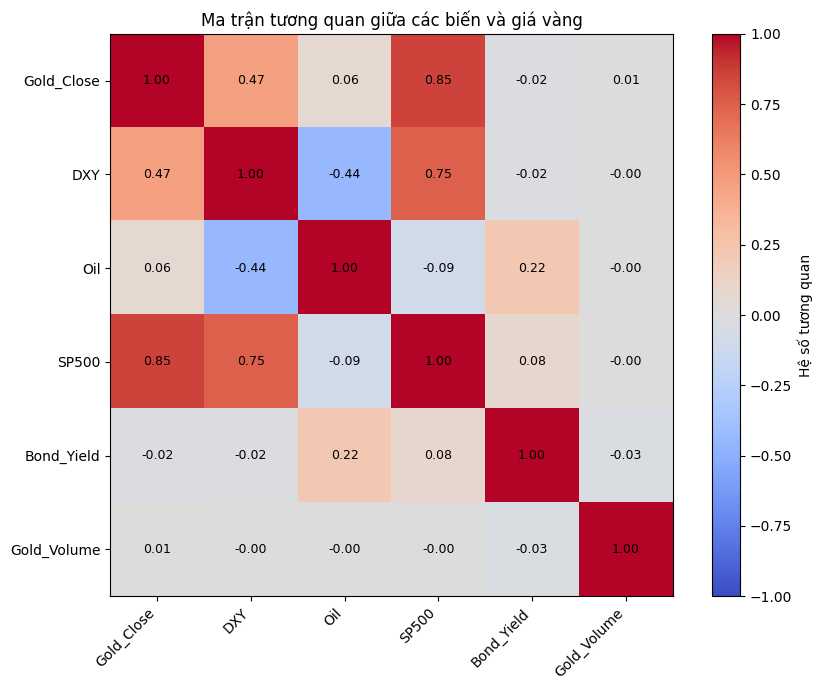

Tương quan với Gold_Close (sắp xếp theo |corr| giảm dần):
SP500          0.851937
DXY            0.468047
Oil            0.061843
Bond_Yield    -0.020511
Gold_Volume    0.006579
Name: Gold_Close, dtype: float64

Biến ảnh hưởng mạnh nhất đến Gold_Close theo tương quan tuyến tính: SP500 (corr = 0.852)


In [10]:
# Tính ma trận tương quan giữa các biến số
corr_df = df_benchmark.drop(columns=['Date']).corr(numeric_only=True)

# Vẽ heatmap tương quan
fig, ax = plt.subplots(figsize=(9, 7))
heatmap = ax.imshow(corr_df.values, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_df.columns)))
ax.set_yticks(np.arange(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_df.columns)

# Ghi giá trị tương quan lên từng ô để dễ đọc
for i in range(corr_df.shape[0]):
    for j in range(corr_df.shape[1]):
        ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=9)

cbar = fig.colorbar(heatmap, ax=ax)
cbar.set_label('Hệ số tương quan')

plt.title('Ma trận tương quan giữa các biến và giá vàng')
plt.tight_layout()
plt.show()

# Xếp hạng mức ảnh hưởng đến Gold_Close theo độ lớn |corr|
gold_corr_rank = corr_df['Gold_Close'].drop('Gold_Close').sort_values(key=lambda x: x.abs(), ascending=False)
print('Tương quan với Gold_Close (sắp xếp theo |corr| giảm dần):')
print(gold_corr_rank)

most_related_feature = gold_corr_rank.index[0]
most_related_value = gold_corr_rank.iloc[0]
print(f"\nBiến ảnh hưởng mạnh nhất đến Gold_Close theo tương quan tuyến tính: {most_related_feature} (corr = {most_related_value:.3f})")

# **PSO-LSTM**

## Hàm mục tiêu cho PSO

In [11]:
def calculate_directional_accuracy(y_true, y_pred):
    """Tính tỉ lệ dự báo đúng hướng tăng/giảm của giá"""
    y_true_diff = np.diff(y_true) > 0
    y_pred_diff = np.diff(y_pred) > 0
    return np.mean(y_true_diff == y_pred_diff) * 100


train_eval_ratio = 0.80
full_train_size = split_index

print(f"PSO sẽ sử dụng dữ liệu đến {df.loc[full_train_size-1, 'Date'].strftime('%Y-%m-%d')} để huấn luyện và tối ưu hóa.")


def objective_function_advanced(x):
    fitness = []
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    for particle in x:
        look_back     = max(30, min(120, int(particle[0])))
        hidden_units  = max(80, min(280, int(particle[1])))
        learning_rate = max(0.0005, min(0.008, particle[2]))
        batch_size    = max(16, min(256, int(particle[3])))
        num_layers    = max(1, min(3, int(particle[4])))
        dropout_rate  = max(0.05, min(0.45, particle[5]))

        try:
            X_all, y_all = create_multivariate_dataset(scaled_data, look_back)
            X_train_sub = X_all[:int(full_train_size * train_eval_ratio)] # train_eval_size
            y_train_sub = y_all[:int(full_train_size * train_eval_ratio)]

            X_val_sub   = X_all[int(full_train_size * train_eval_ratio) : full_train_size]
            y_val_sub   = y_all[int(full_train_size * train_eval_ratio) : full_train_size]

            if len(X_val_sub) == 0:
                # Fallback if validation set is too small, use a portion of train_sub for validation
                val_split_len = max(1, int(len(X_train_sub) * (1 - train_eval_ratio) / train_eval_ratio))
                X_val_sub = X_train_sub[-val_split_len:]
                y_val_sub = y_train_sub[-val_split_len:]
                X_train_sub = X_train_sub[:-val_split_len]
                y_train_sub = y_train_sub[:-val_split_len]


            model = Sequential()
            for i in range(num_layers):
                return_seq = (i < num_layers - 1)
                if i == 0:
                    model.add(LSTM(hidden_units, return_sequences=return_seq,
                                  input_shape=(look_back, num_features)))
                else:
                    model.add(LSTM(hidden_units, return_sequences=return_seq))
                model.add(Dropout(dropout_rate))

            model.add(Dense(1))
            model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

            if len(X_train_sub) == 0 or len(X_val_sub) == 0:
                fitness.append(1e6) # Penalty cao nếu tập huấn luyện/kiểm tra trống
                continue

            model.fit(X_train_sub, y_train_sub,
                      epochs=6,
                      batch_size=batch_size,
                      validation_data=(X_val_sub, y_val_sub),
                      callbacks=[early_stop],
                      verbose=0)

            pred_scaled = model.predict(X_val_sub, verbose=0)
            y_true = scaler_gold.inverse_transform(y_val_sub.reshape(-1, 1)).flatten()
            pred   = scaler_gold.inverse_transform(pred_scaled).flatten()

            rmse = np.sqrt(mean_squared_error(y_true, pred))
            mape = mean_absolute_percentage_error(y_true, pred)

            fitness.append(rmse * (1 + 0.6 * mape))

        except Exception as e:
            fitness.append(1e6) # Penalty cao cho các tham số không hợp lệ hoặc lỗi

    return np.array(fitness)

PSO sẽ sử dụng dữ liệu đến 2026-01-30 để huấn luyện và tối ưu hóa.


## Chạy PSO tối ưu siêu tham số

In [ ]:
import datetime

bounds = ([30, 80, 0.0005, 16, 1, 0.05],
          [120, 280, 0.008, 256, 3, 0.45])

options = {'c1': 2.0, 'c2': 2.0, 'w': 0.9}

optimizer = ps.single.GlobalBestPSO(
    n_particles=12,
    dimensions=6,
    options=options,
    bounds=bounds
)

print("Đang chạy PSO cải thiện...")
start_time = datetime.datetime.now()
print(f"Thời gian bắt đầu: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")

cost, pos = optimizer.optimize(objective_function_advanced, iters=10)

end_time = datetime.datetime.now()
print(f"Thời gian kết thúc: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")

duration = end_time - start_time
print(f"Tổng thời gian chạy PSO: {duration}")

print(f"\nPSO HOÀN THÀNH! Best cost = {cost:.4f}")
print(f"Look-back     : {int(pos[0])}")
print(f"Hidden units  : {int(pos[1])}")
print(f"Learning rate : {pos[2]:.5f}")
print(f"Batch size    : {int(pos[3])}")
print(f"LSTM layers   : {int(pos[4])}")
print(f"Dropout rate  : {pos[5]:.2f}")

2026-04-11 14:22:26,305 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 2.0, 'c2': 2.0, 'w': 0.9}


Đang chạy PSO cải thiện lần cuối...
Thời gian bắt đầu: 2026-04-11 14:22:26


pyswarms.single.global_best: 100%|██████████|10/10, best_cost=78.4
2026-04-11 14:35:13,161 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 78.3564669342189, best pos: [6.87552397e+01 2.10298177e+02 5.37416091e-03 2.48534230e+01
 1.73080102e+00 1.44355470e-01]


Thời gian kết thúc: 2026-04-11 14:35:13
Tổng thời gian chạy PSO: 0:12:46.857767

PSO HOÀN THÀNH! Best cost = 78.3565
Look-back     : 68
Hidden units  : 210
Learning rate : 0.00537
Batch size    : 24
LSTM layers   : 1
Dropout rate  : 0.14


## Huấn luyện mô hình cuối cùng & Đánh giá

In [12]:
best_look_back = int(pos[0])
best_units     = int(pos[1])
best_lr        = float(pos[2])
best_batch     = int(pos[3])
best_layers    = int(pos[4])
best_dropout   = float(pos[5])

# Tạo dataset cuối cùng với best_look_back
X_all, y_all = create_multivariate_dataset(scaled_data, best_look_back)
# Chia tập dữ liệu dựa trên split_index
train_size = split_index - best_look_back # Điều chỉnh train_size để phù hợp với look_back

X_train, y_train = X_all[:train_size], y_all[:train_size]
X_test,  y_test  = X_all[train_size:], y_all[train_size:]

print(f"Kích thước tập huấn luyện: {len(X_train)}")
print(f"Kích thước tập kiểm tra: {len(X_test)}")

# Xây dựng mô hình cuối cùng
final_model = Sequential()
for i in range(best_layers):
    return_seq = (i < best_layers - 1)
    if i == 0:
        final_model.add(LSTM(best_units, return_sequences=return_seq,
                            input_shape=(best_look_back, num_features)))
    else:
        final_model.add(LSTM(best_units, return_sequences=return_seq))
    final_model.add(Dropout(best_dropout))

final_model.add(Dense(1))
final_model.compile(optimizer=Adam(learning_rate=best_lr), loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
print("Huấn luyện Final PSO-LSTM model với best parameters...")
history = final_model.fit(X_train, y_train,
                          epochs=100,
                          batch_size=best_batch,
                          validation_split=0.15,
                          callbacks=[early_stop],
                          verbose=1)

NameError: name 'pos' is not defined

Đánh giá và dự đoán

In [ ]:
# Dự đoán
pred_scaled = final_model.predict(X_test, verbose=0)
pred = scaler_gold.inverse_transform(pred_scaled)
y_true = scaler_gold.inverse_transform(y_test.reshape(-1, 1))

# Metrics PSO-LSTM
mae   = mean_absolute_error(y_true, pred)
rmse  = np.sqrt(mean_squared_error(y_true, pred))
mape  = mean_absolute_percentage_error(y_true, pred) * 100
r2    = r2_score(y_true, pred)
dir_acc = calculate_directional_accuracy(y_true.flatten(), pred.flatten())

print("\n" + "="*80)
print("KẾT QUẢ PSO-LSTM")
print("="*80)
print(f"MAE                  : {mae:.2f} USD")
print(f"RMSE                 : {rmse:.2f} USD")
print(f"MAPE                 : {mape:.2f}%")
print(f"R²                   : {r2:.4f}")
print(f"Directional Accuracy : {dir_acc:.2f}%")
print("="*80)

2026-04-11 14:38:35,548 - tensorflow - WARNING - 5 out of the last 28 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7d2b18d028e0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2026-04-11 14:38:35,647 - tensorflow - WARNING - 6 out of the last 29 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7d2b18d028e0> triggered tf.function retracing. Tracing is expensive and the


KẾT QUẢ PSO-LSTM MULTIVARIATE (TỐI ƯU THEO CÁC NGHIÊN CỨU)
MAE                  : 103.77 USD
RMSE                 : 143.03 USD
MAPE                 : 2.16%
R²                   : 0.6713
Directional Accuracy : 55.32%


## Vẽ biểu đồ dự đoán

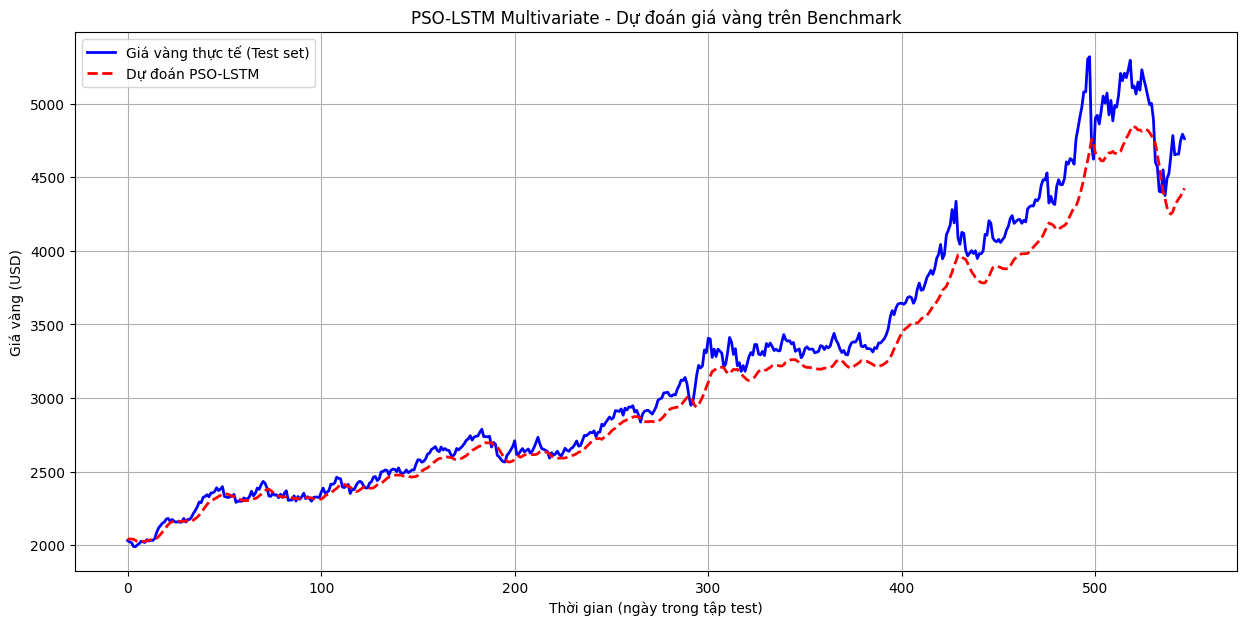

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(y_true, label='Giá vàng thực tế (Test set)', color='blue', linewidth=2)
plt.plot(pred, label='Dự đoán PSO-LSTM', color='red', linestyle='--', linewidth=2)
plt.title('PSO-LSTM Multivariate - Dự đoán giá vàng trên Benchmark')
plt.xlabel('Thời gian (ngày trong tập test)')
plt.ylabel('Giá vàng (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Tải model

In [ ]:
import joblib
import json
from datetime import datetime

# Lưu mô hình Keras
final_model.save('model_PSO_LSTM_final.h5')
print("Đã lưu model: model_PSO_LSTM_final.h5")

# Lưu Scaler
joblib.dump(scaler_gold, 'scaler_gold.pkl')
print("Đã lưu scaler: scaler_gold.pkl")

# Lưu Best Parameters từ PSO
best_params = {
    "look_back": int(pos[0]),
    "hidden_units": int(pos[1]),
    "learning_rate": float(pos[2]),
    "batch_size": int(pos[3]),
    "num_layers": int(pos[4]),
    "dropout_rate": float(pos[5]),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open('best_params.json', 'w') as f:
    json.dump(best_params, f, indent=4)
print("Đã lưu best parameters: best_params.json")

# Lưu Metrics đánh giá
metrics = {
    "MAE": float(mae),
    "RMSE": float(rmse),
    "MAPE": float(mape),
    "R2": float(r2),
    "Directional_Accuracy": float(dir_acc),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("Đã lưu metrics: model_metrics.json")

print("\nLƯU TRỮ HOÀN TẤT!")
print("Các file đã được lưu:")
print("   • model_PSO_LSTM_final.h5")
print("   • scaler_gold.pkl")
print("   • best_params.json")
print("   • model_metrics.json")

2026-04-11 14:39:34,640 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


Đã lưu model: model_PSO_LSTM_final.h5
Đã lưu scaler: scaler_gold.pkl
Đã lưu best parameters: best_params.json
Đã lưu metrics: model_metrics.json

LƯU TRỮ HOÀN TẤT!
Các file đã được lưu:
   • model_PSO_LSTM_final.h5
   • scaler_gold.pkl
   • best_params.json
   • model_metrics.json


# **LSTM BASELINE**

## Xây dựng & Huấn luyện LSTM Baseline

In [ ]:
baseline_look_back = 60
baseline_units     = 128
baseline_layers    = 2
baseline_lr        = 0.001
baseline_dropout   = 0.2
baseline_batch     = 32
baseline_epochs    = 60

# Tạo dataset với look_back cố định
X_all_base, y_all_base = create_multivariate_dataset(scaled_data, baseline_look_back)

# Chia tập dữ liệu dựa trên split_index
train_size_base = split_index - baseline_look_back # Điều chỉnh train_size để phù hợp với look_back

X_train_base = X_all_base[:train_size_base]
y_train_base = y_all_base[:train_size_base]
X_test_base  = X_all_base[train_size_base:]
y_test_base  = y_all_base[train_size_base:]

print(f"Kích thước tập huấn luyện Baseline: {len(X_train_base)}")
print(f"Kích thước tập kiểm tra Baseline: {len(X_test_base)}")

# Xây dựng mô hình Baseline
baseline_model = Sequential()
for i in range(baseline_layers):
    return_seq = (i < baseline_layers - 1)
    if i == 0:
        baseline_model.add(LSTM(baseline_units, return_sequences=return_seq,
                               input_shape=(baseline_look_back, num_features)))
    else:
        baseline_model.add(LSTM(baseline_units, return_sequences=return_seq))
    baseline_model.add(Dropout(baseline_dropout))

baseline_model.add(Dense(1))
baseline_model.compile(optimizer=Adam(learning_rate=baseline_lr), loss='mse')

print("Đang huấn luyện LSTM Baseline...")
baseline_model.fit(X_train_base, y_train_base,
                   epochs=baseline_epochs,
                   batch_size=baseline_batch,
                   validation_split=0.1,
                   verbose=1)

Kích thước tập huấn luyện Baseline: 5253
Kích thước tập kiểm tra Baseline: 48
Đang huấn luyện LSTM Baseline...
Epoch 1/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0012 - val_loss: 0.0042
Epoch 2/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.8050e-04 - val_loss: 0.0030
Epoch 3/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.2204e-04 - val_loss: 0.0040
Epoch 4/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0306e-04 - val_loss: 0.0021
Epoch 5/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.7673e-04 - val_loss: 9.6339e-04
Epoch 6/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.8267e-04 - val_loss: 0.0018
Epoch 7/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.4668e-04 - val_loss: 0.0024
Epoch 8/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.5388e-04 - val_loss: 0.0013
Epoch 9/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3136e-04 - val_loss: 0.0011
Epoch 10/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.3834e-04 - 

In [ ]:
import joblib
import json
import yfinance as yf
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from datetime import datetime, timedelta

print("Đang tải các thành phần mô hình...")
# Tải mô hình
loaded_model = load_model('model_PSO_LSTM_final.h5', compile=False)

# Tải scaler
loaded_scaler_gold = joblib.load('scaler_gold.pkl')

# Tải best parameters
with open('best_params.json', 'r') as f:
    loaded_best_params = json.load(f)

look_back = loaded_best_params['look_back']
print(f"Đã tải model, scaler và các tham số. Look-back: {look_back}")

# === Chuẩn bị dữ liệu thời gian thực cho dự đoán ===
# Tải dữ liệu lịch sử để tạo chuỗi look_back
# Chúng ta cần dữ liệu từ (ngày hiện tại - look_back - vài ngày dự phòng) đến ngày hiện tại
end_date = datetime.now()
start_date_data = end_date - timedelta(days=look_back + 30) # Lấy thêm một khoảng thời gian dự phòng

# Sử dụng hàm lay_du_lieu_nang_cao (đã định nghĩa trước đó)
# Đảm bảo hàm này có sẵn trong notebook

print(f"Đang tải dữ liệu thực tế từ {start_date_data.strftime('%Y-%m-%d')} đến nay...")
realtime_df = lay_du_lieu_nang_cao(start_date=start_date_data.strftime('%Y-%m-%d'))

# Kiểm tra và xử lý dữ liệu
if len(realtime_df) < look_back + 1:
    print(f"Không đủ dữ liệu thời gian thực để tạo chuỗi look-back ({len(realtime_df)} < {look_back + 1}). Vui lòng thử lại sau.")
else:
    # Chỉ lấy các cột tính năng mà mô hình đã được huấn luyện
    features_to_scale = realtime_df.drop(columns=['Date']).columns

    # Áp dụng scaler đã huấn luyện trên toàn bộ tập dữ liệu (đã định nghĩa trong preprocessing)
    # Sử dụng scaler 'scaler' đã được fit trên toàn bộ tập dữ liệu đa biến gốc
    # Lưu ý: cần đảm bảo `scaler` được tạo ở ô ljknvy2d5yf4 đã được chạy
    scaled_realtime_data = scaler.transform(realtime_df[features_to_scale])

    # Lấy chuỗi dữ liệu look_back mới nhất
    X_realtime = scaled_realtime_data[-look_back:].reshape(1, look_back, scaled_realtime_data.shape[1])

    # Dự đoán
    realtime_pred_scaled = loaded_model.predict(X_realtime, verbose=0)
    realtime_pred = loaded_scaler_gold.inverse_transform(realtime_pred_scaled)

    print("\n" + "="*80)
    print(f"DỰ ĐOÁN GIÁ VÀNG CHO NGÀY TIẾP THEO ({end_date.strftime('%Y-%m-%d')} Dữ liệu mới nhất)")
    print("="*80)
    print(f"Giá vàng dự đoán: {realtime_pred[0][0]:.2f} USD")
    print("="*80)

    # Tùy chọn: In ra các dữ liệu đầu vào gần nhất để kiểm tra
    print("\n--- Dữ liệu đầu vào gần nhất được sử dụng ---")
    print(realtime_df.tail(look_back))

[**********************60%****                   ]  3 of 5 completed

Đang tải các thành phần mô hình...
Đã tải model, scaler và các tham số. Look-back: 68
Đang tải dữ liệu thực tế từ 2026-01-03 đến nay...
Đang tải dữ liệu đa biến...


[*********************100%***********************]  5 of 5 completed

Đã tải xong 67 dòng dữ liệu đa biến.
Không đủ dữ liệu thời gian thực để tạo chuỗi look-back (67 < 69). Vui lòng thử lại sau.


## Đánh giá & Bảng so sánh PSO-LSTM vs LSTM Baseline

In [ ]:
# ====================== DỰ ĐOÁN VÀ ĐÁNH GIÁ BASELINE ======================
pred_base_scaled = baseline_model.predict(X_test_base, verbose=0)
pred_base = scaler_gold.inverse_transform(pred_base_scaled)
y_true_base = scaler_gold.inverse_transform(y_test_base.reshape(-1, 1))

# Tính metrics cho Baseline
mae_base   = mean_absolute_error(y_true_base, pred_base)
rmse_base  = np.sqrt(mean_squared_error(y_true_base, pred_base))
mape_base  = mean_absolute_percentage_error(y_true_base, pred_base) * 100
r2_base    = r2_score(y_true_base, pred_base)
dir_acc_base = calculate_directional_accuracy(y_true_base.flatten(), pred_base.flatten())

# ====================== BẢNG SO SÁNH ======================
comparison = pd.DataFrame({
    "Metric": ["MAE (USD)", "RMSE (USD)", "MAPE (%)", "R²", "Directional Accuracy (%)"],
    "PSO-LSTM": [f"{mae:.2f}", f"{rmse:.2f}", f"{mape:.2f}", f"{r2:.4f}", f"{dir_acc:.2f}"],
    "LSTM Baseline": [f"{mae_base:.2f}", f"{rmse_base:.2f}", f"{mape_base:.2f}",
                      f"{r2_base:.4f}", f"{dir_acc_base:.2f}"]
})

print("\n" + "="*80)
print("BẢNG SO SÁNH PSO-LSTM vs LSTM BASELINE")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

# Lưu kết quả so sánh ra file Excel
comparison.to_excel("so_sanh_PSO_vs_Baseline.xlsx", index=False)
print("Đã lưu bảng so sánh vào file: so_sanh_PSO_vs_Baseline.xlsx")


📊 BẢNG SO SÁNH PSO-LSTM vs LSTM BASELINE
                  Metric PSO-LSTM LSTM Baseline
               MAE (USD)   103.77        187.75
              RMSE (USD)   143.03        204.78
                MAPE (%)     2.16          3.80
                      R²   0.6713        0.3261
Directional Accuracy (%)    55.32         42.55
💾 Đã lưu bảng so sánh vào file: so_sanh_PSO_vs_Baseline.xlsx


# Vẽ biểu đồ so sánh hai mô hình

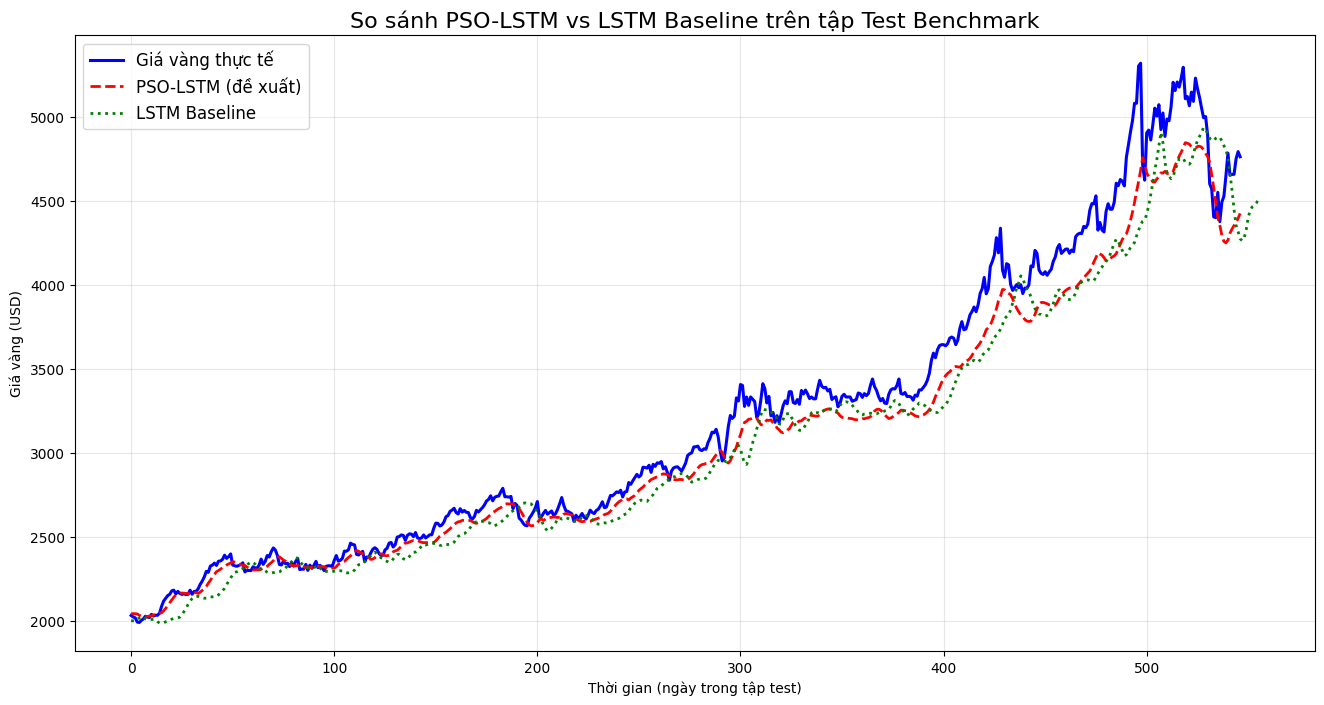

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(y_true, label='Giá vàng thực tế', color='blue', linewidth=2.2)
plt.plot(pred, label='PSO-LSTM (đề xuất)', color='red', linestyle='--', linewidth=2)
plt.plot(pred_base, label='LSTM Baseline', color='green', linestyle=':', linewidth=2)
plt.title('So sánh PSO-LSTM vs LSTM Baseline trên tập Test Benchmark', fontsize=16)
plt.xlabel('Thời gian (ngày trong tập test)')
plt.ylabel('Giá vàng (USD)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# **KIỂM TRA DỰ ĐOÁN TRÊN DỮ LIỆU THỰC TẾ (2 THÁNG QUA)**

Load model đã train (nếu có)

In [13]:
import joblib
import json
import os
from tensorflow.keras.models import load_model

# Kiểm tra sự tồn tại của các file trước khi load
files_required = ['model_PSO_LSTM_final.h5', 'scaler_gold.pkl', 'best_params.json']
missing_files = [f for f in files_required if not os.path.exists(f)]

if not missing_files:
    print("Đang tải model và scaler đã huấn luyện...")
    loaded_model = load_model('model_PSO_LSTM_final.h5', compile=False)
    loaded_scaler_gold = joblib.load('scaler_gold.pkl')
    with open('best_params.json', 'r') as f:
        loaded_best_params = json.load(f)

    # Gán biến look_back từ file config
    look_back = loaded_best_params['look_back']
    print(f"Tải thành công! Look-back dùng cho dự báo: {look_back}")
else:
    print(f"Cảnh báo: Thiếu các file sau để load: {missing_files}")
    print("Vui lòng đảm bảo các ô lưu trữ (cell_id: Fh39n7QvMfyA) đã được thực thi thành công.")

Cảnh báo: Thiếu các file sau để load: ['model_PSO_LSTM_final.h5', 'scaler_gold.pkl', 'best_params.json']
Vui lòng đảm bảo các ô lưu trữ (cell_id: Fh39n7QvMfyA) đã được thực thi thành công.


[*********************100%***********************]  5 of 5 completed

Đang lấy dữ liệu từ 2026-02-10 đến 2026-04-11...



KẾT QUẢ KIỂM TRA THỰC TẾ (60 NGÀY QUA)
Số ngày kiểm tra      : 29
Sai số tuyệt đối (MAE): 105.98 USD
Sai số phần trăm (MAPE): 2.25%
Độ chính xác xu hướng : 53.57%


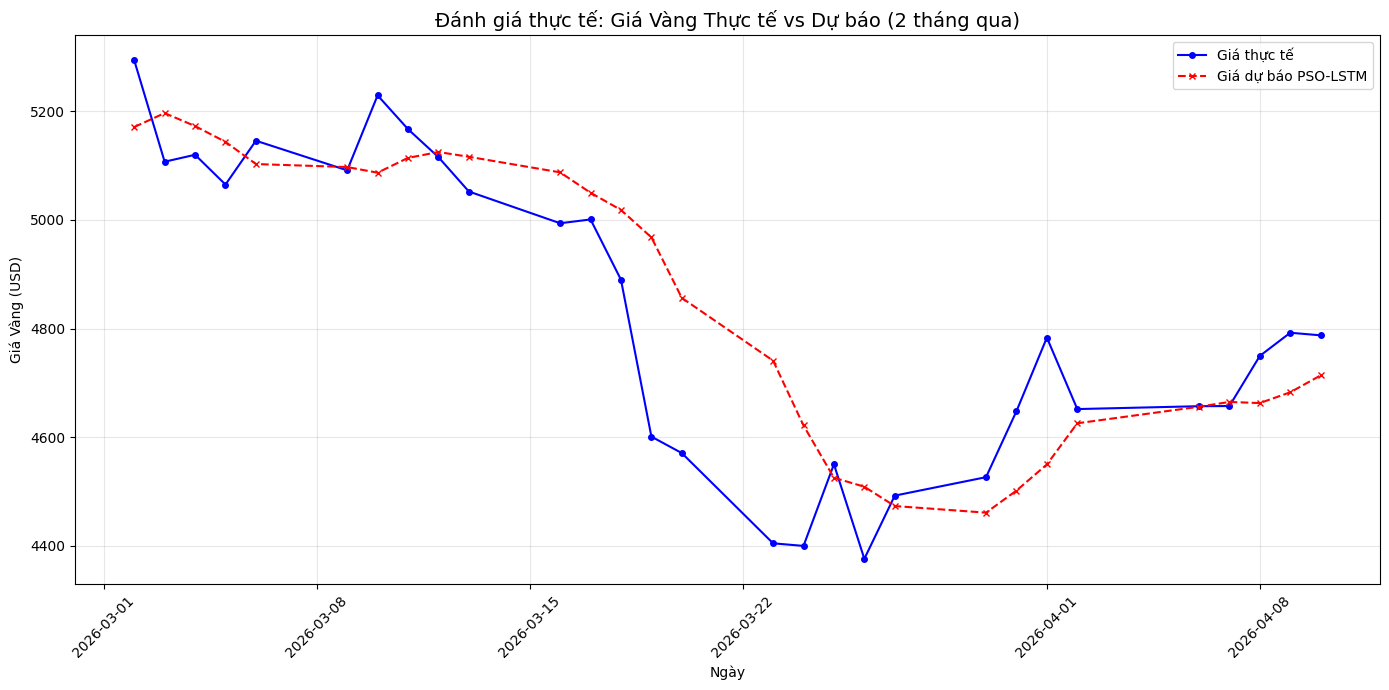

In [19]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# 1. Xác định khoảng thời gian: 2 tháng trước đến hôm qua
end_dt = datetime.now() - timedelta(days=1)
start_dt = end_dt - timedelta(days=60)

# Lấy look_back từ các tham số đã load (biến look_back đã được định nghĩa ở ô load model)
current_look_back = look_back

print(f"Đang lấy dữ liệu từ {start_dt.strftime('%Y-%m-%d')} đến {end_dt.strftime('%Y-%m-%d')}...")

# Tải dữ liệu (lấy dư look_back ngày để có đủ đầu vào)
extended_start_dt = start_dt - timedelta(days=current_look_back + 15)
real_df = lay_du_lieu_nang_cao(start_date=extended_start_dt.strftime('%Y-%m-%d'))

# Lọc bỏ các ngày sau 'hôm qua'
real_df = real_df[real_df['Date'] <= end_dt]

# 2. Tiền xử lý
# Sử dụng scaler đa biến đã định nghĩa trước đó
features_cols = real_df.drop(columns=['Date']).columns
scaled_real = scaler.transform(real_df[features_cols])

# Tạo dataset để test theo dạng trượt (sliding window)
X_real, y_real_scaled = [], []
for i in range(current_look_back, len(scaled_real)):
    X_real.append(scaled_real[i-current_look_back:i, :])
    y_real_scaled.append(scaled_real[i, 0])

X_real = np.array(X_real)
y_real_scaled = np.array(y_real_scaled)

# 3. Dự đoán bằng model đã load
pred_real_scaled = loaded_model.predict(X_real, verbose=0)
pred_real = loaded_scaler_gold.inverse_transform(pred_real_scaled).flatten()
y_real_actual = loaded_scaler_gold.inverse_transform(y_real_scaled.reshape(-1, 1)).flatten()

# 4. Tính toán Metrics
mae_real = mean_absolute_error(y_real_actual, pred_real)
mape_real = mean_absolute_percentage_error(y_real_actual, pred_real) * 100
dir_acc_real = calculate_directional_accuracy(y_real_actual, pred_real)

print("\n" + "="*50)
print(f"KẾT QUẢ KIỂM TRA THỰC TẾ (60 NGÀY QUA)")
print("="*50)
print(f"Số ngày kiểm tra      : {len(y_real_actual)}")
print(f"Sai số tuyệt đối (MAE): {mae_real:.2f} USD")
print(f"Sai số phần trăm (MAPE): {mape_real:.2f}%")
print(f"Độ chính xác xu hướng : {dir_acc_real:.2f}%")
print("="*50)

# 5. Vẽ biểu đồ so sánh
plt.figure(figsize=(14, 7))
plt.plot(real_df['Date'].iloc[-len(y_real_actual):], y_real_actual, label='Giá thực tế', color='blue', marker='o', markersize=4)
plt.plot(real_df['Date'].iloc[-len(y_real_actual):], pred_real, label='Giá dự báo PSO-LSTM', color='red', linestyle='--', marker='x', markersize=4)
plt.title(f'Đánh giá thực tế: Giá Vàng Thực tế vs Dự báo (2 tháng qua)', fontsize=14)
plt.xlabel('Ngày')
plt.ylabel('Giá Vàng (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()